# <p style="font-family: 'Amiri'; font-size: 2rem; color: #4a2a28; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #fad4d2; padding: 30px; border-radius: 20px; border: 8px solid #4a2a28; width:90%">˚Predicting Wine Quality with AI˚</p>

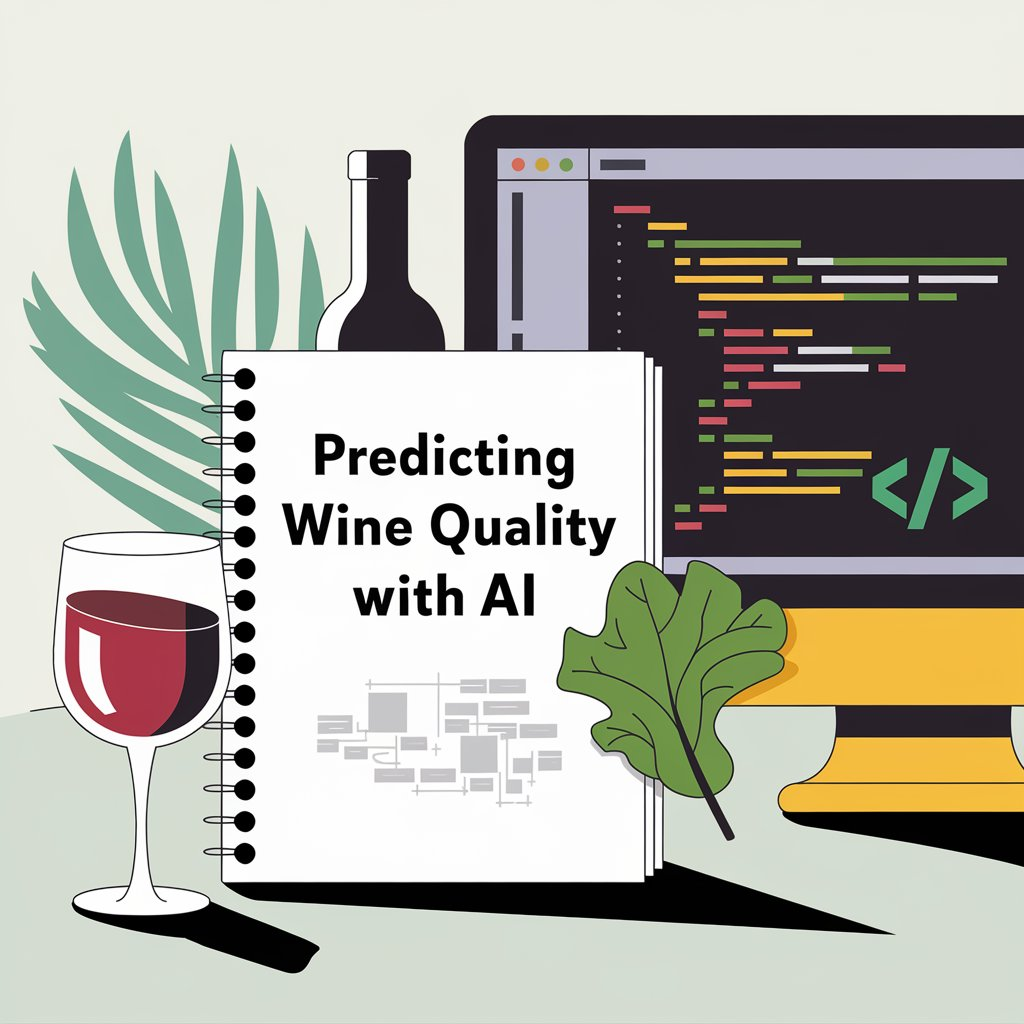

# <p style="font-family: 'Amiri'; font-size: 2rem; color: #4a2a28; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #fad4d2; padding: 10px; border-radius: 20px; border: 8px solid #4a2a28; width:90%">Import Dependencies</p>

In [1]:
# Import Basis
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from catboost import CatBoostClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold
from catboost import CatBoostClassifier, Pool
from imblearn.over_sampling import SMOTE
from IPython.core.display import display, HTML

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Palette
palette = ['#4a2a28', '#fad4d2']
color_palette = sns.color_palette(palette)

# Set the option to display all columns
pd.set_option('display.max_columns', None)

# <p style="font-family: 'Amiri'; font-size: 2rem; color: #4a2a28; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #fad4d2; padding: 10px; border-radius: 20px; border: 8px solid #4a2a28; width:90%">Load Train and Test Data</p>

In [2]:
# Load datasets
train = pd.read_csv("/kaggle/input/ai-competition-africa/train.csv") 
test = pd.read_csv("/kaggle/input/ai-competition-africa/test.csv")
submission = pd.read_csv("/kaggle/input/ai-competition-africa/sample_submission.csv")

# <p style="font-family: 'Amiri'; font-size: 2rem; color: #4a2a28; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #fad4d2; padding: 10px; border-radius: 20px; border: 8px solid #4a2a28; width:90%">Basic Overview</p>

In [4]:
def styled_heading(text, background_color='#fad4d2', text_color='#4a2a28'):
    return f"""
    <div style="
        text-align: center;
        background: {background_color};
        font-family: 'Montserrat', sans-serif;
        color: {text_color};
        padding: 15px;
        font-size: 30px;
        font-weight: bold;
        line-height: 1;
        border-radius: 20px 20px 0 0;
        margin: 20px 0;  /* Added margin for spacing */
        box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.2);
        border: 3px dashed {text_color};
    ">
        {text}
    </div>
    """

def D_O(train_df, heading_bg='lightblue', heading_color='black', text_bg='white', text_color='black'):
    try:
        # Display head and tail of the training dataset nicely
        for heading, df_part in zip(
            ["The Head Of Dataset is:", "The Tail Of Dataset is:", "Numerical Summary of Data:"], 
            [train_df.head(5), train_df.tail(5), train_df.describe()]
        ):
            display(HTML(styled_heading(heading, background_color=heading_bg, text_color=heading_color)))
            display(HTML(df_part.to_html(index=False).replace(
                '<table border="1" class="dataframe">', 
                f'<table style="border: 8px solid black; margin-bottom: 20px; background-color: {text_bg}; color: {text_color};">'
            ).replace('<td>', f'<td style="color: {text_color}; background-color: {text_bg};">')))
            print("\n")  

        # Print shape data
        display(HTML(styled_heading("Shape Data:", background_color=heading_bg, text_color=heading_color)))
        print(f'Shape of the Data: {train_df.shape}')
        print(f'Rows: {train_df.shape[0]}')
        print(f'Columns: {train_df.shape[1]}')
        print("\n<br>\n")  

        # Print info of train data
        display(HTML(styled_heading("Info Of Data:", background_color=heading_bg, text_color=heading_color)))
        buffer = StringIO()
        train_df.info(buf=buffer)
        buffer.seek(0)
        info_str = buffer.read()
        display(HTML(f"<pre style='color: {text_color}; background-color: {text_bg}; margin-bottom: 20px; font-family: Courier, monospace; font-size: 14px; padding: 10px; border: 8px solid black;'>{info_str}</pre>"))
        print("\n<br>\n")  # Adding space between sections

        # Print categorical columns
        Cat_cols_train = [col for col in train_df.columns if train_df[col].dtype == 'O']
        display(HTML(styled_heading("Categorical Columns of Data:", background_color=heading_bg, text_color=heading_color)))
        print(f'The Categorical Columns of Data are: {Cat_cols_train}')
        print("\n<br>\n")  # Adding space between sections

        # Print numerical columns
        N_cols_train = [col for col in train_df.columns if train_df[col].dtype == 'float']
        display(HTML(styled_heading("Numerical Columns of Data:", background_color=heading_bg, text_color=heading_color)))
        print(f'The Numerical Columns of Data are: {N_cols_train}')
        print("\n<br>\n")  # Adding space between sections

        # Print null values
        display(HTML(styled_heading("Null Values in Data:", background_color=heading_bg, text_color=heading_color)))
        null_values = train_df.isnull().sum()
        display(HTML(f"<pre style='color: {text_color}; background-color: {text_bg}; margin-bottom: 20px; font-family: Courier, monospace; font-size: 14px; padding: 10px; border: 8px solid black;'>{null_values}</pre>"))
        print("\n<br>\n")  
        
        # Print duplicates check
        display(HTML(styled_heading("Duplicates Check in Data:", background_color=heading_bg, text_color=heading_color)))
        if train_df.duplicated().any():
            print(f'Duplicates exist in the dataset.')
        else:
            print(f'No duplicates found in the dataset.')
        print("\n<br>\n")  

    except Exception as e:
        print_error(str(e))

# <p style="font-family: 'Amiri'; font-size: 2rem; color: #4a2a28; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #fad4d2; padding: 20px; border-radius: 20px; border: 8px solid #4a2a28; width:30%">Train Data</p>

In [5]:
D_O(train, heading_bg='#fad4d2', heading_color='#4a2a28', text_bg='#fad4d2', text_color='#4a2a28')

id,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.43,0.03,1.7,0.084,8.0,17.0,0.99680,3.50,0.54,9.3,5.0
1,8.2,0.59,0.30,1.7,0.074,6.0,17.0,0.99640,3.12,0.61,11.9,5.0
2,8.3,0.36,0.39,2.6,0.090,29.0,44.0,0.99680,3.21,0.71,11.2,6.0
3,7.8,0.49,0.21,1.9,0.082,8.0,18.0,0.99770,3.24,0.57,9.6,6.0
4,7.3,0.68,0.05,2.3,0.078,9.0,30.0,0.99489,3.31,0.73,12.4,6.0


id,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
14995,6.7,0.570,0.02,2.3,0.084,7.0,28.0,0.99760,3.45,0.71,9.2,5.0
14996,11.5,0.610,0.60,1.7,0.077,27.0,52.0,0.99572,3.24,0.58,10.9,5.0
14997,8.3,0.715,0.14,2.2,0.060,3.0,10.0,0.99800,3.40,0.58,11.7,6.0
14998,7.7,0.380,0.20,1.6,0.079,19.0,35.0,0.99606,3.31,0.60,11.2,6.0
14999,11.9,0.430,0.49,3.0,0.074,6.0,12.0,0.99760,3.17,0.55,12.4,7.0


id,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
7499.500000,8.148521,0.506920,0.230367,2.197374,0.078649,13.157567,37.134467,0.996915,3.321316,0.618763,10.187300,5.649867
4330.271354,1.395131,0.135442,0.178627,0.536517,0.012905,7.875768,24.059479,0.001409,0.115716,0.106382,0.899063,0.810011
0.000000,4.000000,0.120000,0.000000,0.650000,0.012000,1.000000,4.000000,0.990640,2.880000,0.390000,8.800000,3.000000
3749.750000,7.200000,0.400000,0.050000,1.900000,0.073000,6.000000,19.000000,0.995900,3.240000,0.550000,9.500000,5.000000
7499.500000,7.800000,0.510000,0.240000,2.100000,0.078000,12.000000,30.000000,0.996800,3.320000,0.590000,9.900000,6.000000
11249.250000,8.900000,0.600000,0.390000,2.400000,0.084000,17.000000,48.000000,0.997800,3.390000,0.660000,10.800000,6.000000
14999.000000,18.000000,1.580000,0.760000,15.000000,0.415000,52.000000,165.000000,1.003690,4.010000,1.680000,16.000000,8.000000


Shape of the Data: (15000, 13)
Rows: 15000
Columns: 13

<br>




<br>



The Categorical Columns of Data are: []

<br>



The Numerical Columns of Data are: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

<br>




<br>



No duplicates found in the dataset.

<br>



# <p style="font-family: 'Amiri'; font-size: 2rem; color: #4a2a28; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #fad4d2; padding: 10px; border-radius: 20px; border: 8px solid #4a2a28; width:90%">Insights From Train Data</p>

- **Shape of the Data**: 
    - Rows: `15,000`
    - Columns: `13`
- **Column Information**: 
    - The dataset contains **12 numerical columns** and **1 categorical column** (`id`).
- **Null Values**: 
    - No missing data across any of the columns, which is a good sign for analysis.
- **Duplicates**: 
    - There are **no duplicate records** found in the dataset.

---

## **Numerical Summary**

- **Central Tendency** (Mean):
    - The **average values** for some key features are as follows:
        - **Fixed Acidity**: `8.15`
        - **Alcohol**: `10.19`
        - **Quality**: `5.65`
    - The **quality** ratings vary from `3` to `8`, indicating a mix of low and high-quality wines.

- **Dispersion** (Standard Deviation):
    - **Residual Sugar**: `2.20`
    - **Alcohol**: `0.90`
    - These values show significant variability, especially in residual sugar and alcohol content.

---

## **Data Distribution** (Range, Mean, and Standard Deviation):

| Feature                 | Range (Min - Max)        | Mean    | Std Dev   |
|-------------------------|--------------------------|---------|-----------|
| **Fixed Acidity**        | 4.0 - 18.0               | 8.15    | 1.40      |
| **Volatile Acidity**     | 0.12 - 1.58              | 0.51    | 0.14      |
| **Citric Acid**          | 0.00 - 0.76              | 0.23    | 0.18      |
| **Residual Sugar**       | 0.00 - 15.00             | 2.20    | 2.10      |
| **Chlorides**            | 0.01 - 0.42              | 0.08    | 0.02      |
| **Free Sulfur Dioxide**  | 1.00 - 52.00             | 13.16   | 7.88      |
| **Total Sulfur Dioxide** | 4.00 - 165.00            | 37.13   | 24.06     |
| **Density**              | 0.99 - 1.00              | 0.997   | 0.0014    |
| **pH**                   | 2.88 - 4.01              | 3.32    | 0.11      |
| **Sulphates**            | 0.39 - 1.68              | 0.62    | 0.11      |
| **Alcohol**              | 8.80 - 16.00             | 10.19   | 0.90      |
| **Quality**              | 3 - 8                    | 5.65    | 0.81      |

---

## **Feature Insights** 

- **Fixed Acidity**: 
    - The values of fixed acidity range from **4.0 to 18.0**. The **mean** value is around **8.15**, indicating a fairly typical acidity level for most wines in the dataset.

- **Volatile Acidity**: 
    - A critical parameter for wine quality, volatile acidity ranges from **0.12** to **1.58**. Wines with high volatile acidity may not taste as good, and the mean is around **0.51**, pointing to a balanced distribution of this characteristic.

- **Citric Acid**: 
    - With a mean of **0.23** and a maximum value of **0.76**, citric acid is a less dominant feature in the wines within this dataset. This may correlate with the smoothness of the wine.

- **Residual Sugar**: 
    - A more variable feature, with residual sugar ranging from **0.0** to **15.0**, with a mean of **2.20**. This suggests that many wines in the dataset have low sugar content, but a few have higher sugar content, which could affect the quality.

- **Alcohol**: 
    - Alcohol content ranges from **8.8%** to **16%**, with an average of **10.19%**. Wines with a higher alcohol content might generally be stronger in taste, and this is a common feature influencing wine quality.

- **Quality**: 
    - The **quality** ratings range from **3 to 8**, with a mean of **5.65**. This means that most wines in the dataset are average quality, with relatively few wines rated extremely low or high.

---

## **Final Observations**

- **No Missing Data**: The dataset is clean, with no missing or null values, which simplifies the data preprocessing stage.
- **Good Quality Data**: There are no duplicates, ensuring data integrity.
- **Balance in Features**: Features such as alcohol and sulphates seem to have reasonable distributions, with some variability in others like residual sugar and total sulfur dioxide, which could be interesting to explore further.

# <p style="font-family: 'Amiri'; font-size: 2rem; color: #4a2a28; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #fad4d2; padding: 20px; border-radius: 20px; border: 8px solid #4a2a28; width:30%">Test Data</p>

In [6]:
D_O(test, heading_bg='#fad4d2', heading_color='#4a2a28', text_bg='#fad4d2', text_color='#4a2a28')

id,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
15000,7.0,0.620,0.02,1.9,0.074,6.0,18.0,0.99728,3.35,0.61,9.7
15001,8.1,0.580,0.10,4.6,0.091,15.0,34.0,0.99576,3.43,0.59,9.5
15002,8.0,0.500,0.19,2.1,0.080,23.0,62.0,0.99640,3.47,0.59,10.8
15003,12.8,0.400,0.49,3.3,0.083,7.0,18.0,0.99780,3.10,0.62,10.6
15004,7.1,0.615,0.22,2.6,0.044,21.0,49.0,0.99640,3.33,0.62,9.5


id,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
24995,6.6,0.65,0.15,2.2,0.080,15.0,26.0,0.99600,3.54,0.44,9.5
24996,7.3,0.41,0.32,2.8,0.069,14.0,37.0,0.99730,3.29,0.84,9.3
24997,9.4,0.60,0.44,2.3,0.093,10.0,32.0,0.99780,3.26,0.87,9.5
24998,8.2,0.53,0.20,2.2,0.080,31.0,131.0,0.99652,3.39,0.51,9.5
24999,7.3,0.58,0.02,2.1,0.092,9.0,28.0,0.99780,3.36,0.55,9.9


id,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
19999.50000,8.153390,0.505051,0.229062,2.192626,0.07850,13.222750,37.378850,0.996904,3.323718,0.616092,10.193979
2886.89568,1.399736,0.134771,0.176771,0.536688,0.01402,7.825339,24.205621,0.001411,0.115484,0.104812,0.895827
15000.00000,4.100000,0.120000,0.000000,1.200000,0.01200,1.000000,6.000000,0.990640,2.880000,0.390000,8.100000
17499.75000,7.200000,0.400000,0.040000,1.900000,0.07300,6.000000,20.000000,0.995860,3.250000,0.550000,9.500000
19999.50000,7.800000,0.510000,0.240000,2.100000,0.07800,12.000000,31.000000,0.996800,3.320000,0.590000,9.900000
22499.25000,8.900000,0.600000,0.370000,2.300000,0.08300,17.000000,48.000000,0.997800,3.390000,0.660000,10.800000
24999.00000,15.600000,1.580000,0.760000,8.800000,0.41500,52.000000,278.000000,1.003150,3.740000,1.610000,14.000000


Shape of the Data: (10000, 12)
Rows: 10000
Columns: 12

<br>




<br>



The Categorical Columns of Data are: []

<br>



The Numerical Columns of Data are: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

<br>




<br>



No duplicates found in the dataset.

<br>



# <p style="font-family: 'Amiri'; font-size: 2rem; color: #4a2a28; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #fad4d2; padding: 10px; border-radius: 20px; border: 8px solid #4a2a28; width:90%">Insights from Test Data</p>

1. **Dataset Overview**:
   - The dataset contains **10,000 rows** and **12 columns**, indicating a reasonably large dataset with diverse features for analysis.
   - There are **no missing values** in any of the columns, ensuring data integrity and eliminating the need for imputation or missing value handling.
   - The dataset has **no duplicate entries**, which means the data is unique and reliable for analysis.

2. **Columns Breakdown**:
   - All columns are **numerical**, and there are **no categorical features**, simplifying the analysis as we can focus on continuous data.

3. **Statistical Summary**:
   - The **mean** values of features like **fixed acidity**, **volatile acidity**, **citric acid**, and **alcohol** give us an overall understanding of the wine characteristics.
     - **Fixed acidity** has a mean of **8.15**, and **alcohol** has a mean of **10.19**, which are significant indicators of wine quality.
   - The **standard deviation** values highlight the variance in the dataset, with certain features like **total sulfur dioxide** and **sulphates** having a higher range of values.
   - The **maximum and minimum** values indicate the spread of wine qualities. For instance, **fixed acidity** ranges from **4.1** to **15.6**, while **alcohol** varies from **8.1** to **14**.

4. **Data Distribution**:
   - The **fixed acidity** values show a wide spread, with **15.6** being the maximum and **4.1** being the minimum, indicating different levels of acidity in the wines.
   - The **alcohol content** varies from **8.1** to **14**, suggesting diverse types of wines in terms of alcohol strength.

5. **Density & pH Levels**:
   - The **density** values range from **0.990640** to **1.003150**, with a mean of **0.996904**, which can provide insight into the overall consistency and weight of the wines.
   - The **pH levels** are concentrated between **2.88** and **3.74**, which suggests that the wines are predominantly acidic.

6. **Insights from Tail of the Dataset**:
   - The wines in the dataset have a **wide range of sulfur dioxide** values, with **total sulfur dioxide** reaching as high as **278** in some entries.
   - The **citric acid** content, which has a max value of **0.76**, shows variability across different wine types.
   - The **sulphates** and **chlorides** also exhibit variability, which might impact wine quality.

7. **No Categorical Data**:
   - The dataset contains only **numerical data**, which simplifies the analysis but limits the ability to assess wine quality through categorical features.

# <p style="font-family: 'Amiri'; font-size: 2rem; color: #4a2a28; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #fad4d2; padding: 10px; border-radius: 20px; border: 8px solid #4a2a28; width:90%">Target Distribution</p>

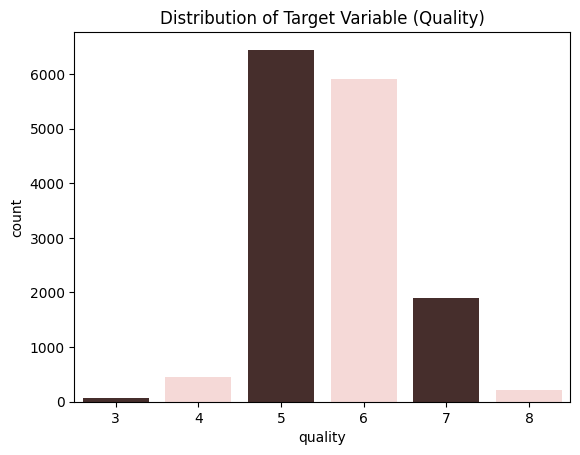

In [17]:
# Target distribution
sns.countplot(x='quality', data=train, palette=color_palette)
plt.title("Distribution of Target Variable (Quality)")
plt.show()

## **Insights from the Target Variable (Quality) Distribution**

1. **Imbalanced Distribution**:
   - The target variable (`quality`) exhibits an imbalanced distribution.
   - Most samples fall in the `5` and `6` quality categories, making these the dominant classes.

2. **Minority Classes**:
   - Classes `3`, `4`, and `8` have significantly fewer samples, indicating potential challenges in model training due to class imbalance.
   - These minority classes may require oversampling (e.g., SMOTE) or class weighting during model training.

3. **Class Spread**:
   - The target variable covers a range of values from `3` to `8`, confirming the ordinal nature of the quality ratings.

4. **Potential Challenges**:
   - Without addressing the class imbalance, the model might bias predictions toward the majority classes (`5` and `6`).
   - Strategies like SMOTE, class weighting, or specialized loss functions (e.g., Quadratic Weighted Kappa) will be essential for improving model performance on minority classes.

---

These insights highlight the need for preprocessing techniques to ensure fair treatment of all classes during training.


# <p style="font-family: 'Amiri'; font-size: 2rem; color: #4a2a28; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #fad4d2; padding: 10px; border-radius: 20px; border: 8px solid #4a2a28; width:90%">Correlation</p>

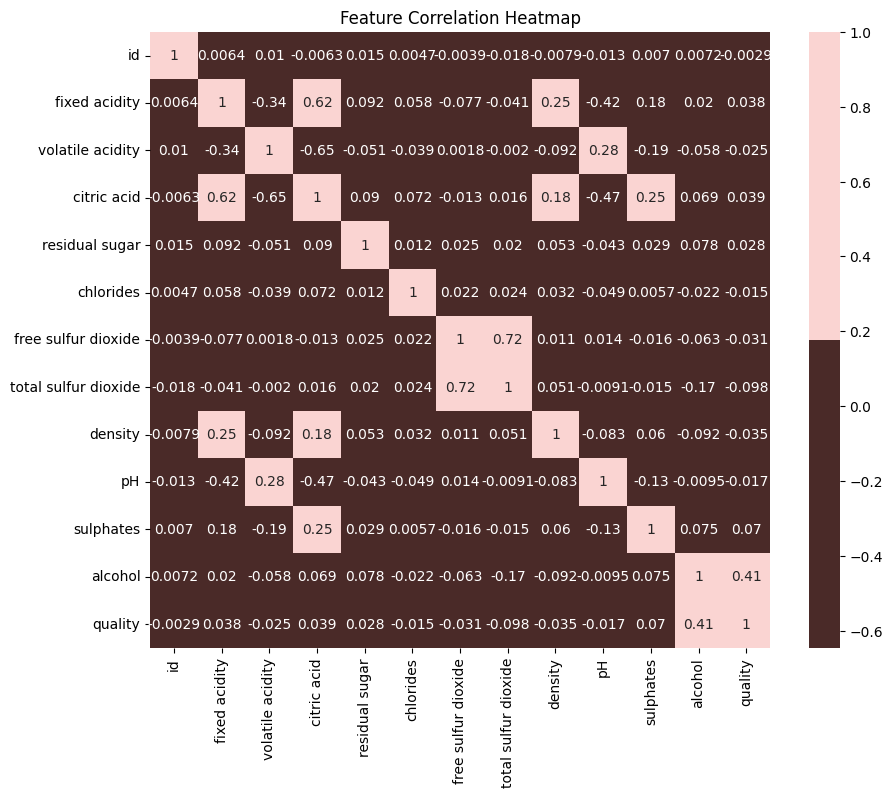

In [18]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(train.corr(), annot=True, cmap=color_palette)
plt.title("Feature Correlation Heatmap")
plt.show()

## **Insights from Feature Correlation Heatmap**

1. **Strong Positive Correlations**:
   - `fixed acidity` and `citric acid` show a strong positive correlation (r ≈ 0.62), indicating that these features might be interdependent.
   - `free sulfur dioxide` and `total sulfur dioxide` are highly correlated (r ≈ 0.72), suggesting redundancy or shared influence on wine quality.

2. **Significant Relationships with Quality**:
   - `alcohol` has the highest positive correlation with the target variable (`quality`) (r ≈ 0.41), making it a key predictor for wine quality.
   - `density` and `total sulfur dioxide` show negative correlations with `quality` (r ≈ -0.09 and r ≈ -0.098, respectively), suggesting that higher levels of these features might negatively impact wine quality.

3. **Weak or Negligible Correlations**:
   - Features like `chlorides`, `residual sugar`, and `volatile acidity` have very weak correlations with `quality`, indicating they might not contribute significantly to predicting the target variable.

4. **Multicollinearity**:
   - Features like `fixed acidity` and `citric acid`, as well as `free sulfur dioxide` and `total sulfur dioxide`, exhibit strong intercorrelations, which might lead to multicollinearity issues in certain models. Dimensionality reduction or feature selection may be required.

5. **Independent Features**:
   - Some features like `pH` and `sulphates` appear to have moderate or no direct relationships with other features, making them potentially unique contributors to the model.

---

These insights will guide feature engineering and selection, ensuring better model performance while avoiding redundancy and overfitting.


# <p style="font-family: 'Amiri'; font-size: 2rem; color: #4a2a28; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #fad4d2; padding: 10px; border-radius: 20px; border: 8px solid #4a2a28; width:90%">Model Building</p>

# <p style="font-family: 'Amiri'; font-size: 2rem; color: #4a2a28; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #fad4d2; padding: 10px; border-radius: 20px; border: 8px solid #4a2a28; width:90%">Code Working</p>

## **Code Explanation**

### **1. Quadratic Weighted Kappa (QWK) Metric**
- The `quadratic_weighted_kappa_loss` function calculates the Quadratic Weighted Kappa (QWK), a metric that measures agreement between two ordinal variables (e.g., predicted and actual quality scores).
- **Steps:**
  1. Compute the confusion matrix to analyze prediction accuracy.
  2. Calculate a weight matrix based on the squared differences between predicted and true ratings, normalized by the total range.
  3. Estimate an expected matrix, assuming predictions are distributed uniformly based on actual ratings.
  4. Use the weight and expected matrices to compute QWK, ranging from -1 (complete disagreement) to 1 (perfect agreement).

---

### **2. Data Preparation**
- The dataset is split into features (`X`) and the target variable (`y`), where:
  - `X`: Predictor variables (excluding `quality` and `id`).
  - `y`: Target variable `quality`, which is converted to integers for compatibility with `CatBoostClassifier`.
- Unique classes in the target are identified and stored in `unique_classes`, ensuring consistency throughout the pipeline.

---

### **3. Class Balancing Using SMOTE**
- **Synthetic Minority Oversampling Technique (SMOTE)**:
  - Addresses class imbalance by oversampling minority classes to match the majority class distribution.
  - Ensures the classifier doesn’t overfit the majority class during training.
  - Balanced feature matrix (`X_res`) and target labels (`y_res`) are created.

---

### **4. Dynamic Class Weights**
- Class weights are initialized based on the number of unique classes in the dataset.
- These weights are passed to the CatBoost model to ensure fair treatment of all classes during training.

---

### **5. Model Parameters**
- A `CatBoostClassifier` is used, configured with the following:
  - **Iterations**: 700 boosting iterations for training.
  - **Learning Rate**: 0.05 for gradual convergence.
  - **Depth**: 8 for capturing interactions between variables.
  - **L2 Regularization**: 3.5 to prevent overfitting.
  - **Random Strength**: Adds randomness to feature splits to increase model robustness.
  - **Bagging Temperature**: 0.8 for sample selection during training.
  - **Loss Function**: `MultiClass` for multi-class classification.
  - **Evaluation Metric**: `TotalF1` for validation during training.
  - **Class Weights**: Ensures balanced class learning.
  - **Early Stopping**: Stops training if the evaluation metric doesn’t improve after 50 rounds.

---

### **6. Cross-Validation with K-Fold**
- **K-Fold Cross-Validation**:
  - Splits data into 5 folds, ensuring every fold is used for validation once.
  - Provides a robust measure of model performance and reduces overfitting.
- For each fold:
  1. The model is trained on the training set and validated on the validation set.
  2. Predictions are generated for the validation set.
  3. The QWK score is computed using the `quadratic_weighted_kappa_loss` function.
  4. Predictions for the test set are stored for aggregation later.

---

### **7. Aggregating Test Predictions**
- After cross-validation, predictions from all folds are averaged to create a final prediction.
- **Steps:**
  - Take the mean of predictions from all folds.
  - Round predictions to the nearest integer and ensure they are within the valid class range using `np.clip`.

---

### **8. Saving Final Predictions**
- The distribution of final predictions is displayed for validation.
- A submission file is created, containing:
  - `id`: Unique identifiers from the test set.
  - `quality`: Final predicted quality scores.
- The submission file is saved as `submission_optimized.csv`.

---

### **Why Use QWK and SMOTE?**
- **QWK**:
  - Essential for ordinal classification tasks where the order of classes matters (e.g., quality ratings).
  - Encourages predictions closer to the true value, penalizing large discrepancies.
- **SMOTE**:
  - Balances the dataset, ensuring the model doesn’t bias toward majority classes.

---

### **Results**
- The code computes QWK for each fold and summarizes the average performance across folds.
- The submission file contains predictions optimized using cross-validation and balanced learning techniques.


In [9]:
# QWK metric for CatBoost
def quadratic_weighted_kappa_loss(y_true, y_pred):
    """Computes Quadratic Weighted Kappa."""
    # Confusion matrix
    conf_matrix = confusion_matrix(y_true, y_pred)
    num_ratings = len(conf_matrix)
    weights = np.zeros((num_ratings, num_ratings))

    for i in range(num_ratings):
        for j in range(num_ratings):
            weights[i, j] = ((i - j) ** 2) / (num_ratings - 1) ** 2

    hist_true = np.sum(conf_matrix, axis=1)
    hist_pred = np.sum(conf_matrix, axis=0)
    expected_matrix = np.outer(hist_true, hist_pred) / np.sum(conf_matrix)

    kappa = 1 - (np.sum(weights * conf_matrix) / np.sum(weights * expected_matrix))
    return kappa

# Prepare the data
X = train.drop(columns=['quality', 'id'])
y = train['quality'].astype(int)

# Check unique classes in the target variable
unique_classes = sorted(y.unique())
print(f"Unique classes in the target: {unique_classes}")

# SMOTE for class balancing
smote = SMOTE(random_state=42, sampling_strategy="not majority")
X_res, y_res = smote.fit_resample(X, y)

# Update class weights dynamically based on the number of unique classes
class_weights = [1.0] * len(unique_classes)
print(f"Adjusted class weights: {class_weights}")

# Initialize KFold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Custom Parameters for CatBoostClassifier
params = {
    'iterations': 700,               
    'learning_rate': 0.05,           
    'depth': 8,                      
    'l2_leaf_reg': 3.5,              
    'random_strength': 1.5,          
    'bagging_temperature': 0.8,      
    'loss_function': 'MultiClass',
    'eval_metric': 'TotalF1',        
    'boosting_type': 'Plain',        
    'random_seed': 42,
    'verbose': 200,                  
    'class_weights': class_weights   
}

# Lists to store results
qwk_scores = []
test_predictions = []

# Cross-Validation Training
for fold, (train_idx, val_idx) in enumerate(kf.split(X_res, y_res), 1):
    print(f"Training Fold {fold}...")

    # Train and validation splits
    X_train, X_val = X_res.iloc[train_idx], X_res.iloc[val_idx]
    y_train, y_val = y_res.iloc[train_idx], y_res.iloc[val_idx]

    # Initialize the model
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train, 
              eval_set=Pool(X_val, y_val), 
              early_stopping_rounds=50)

    # Make predictions on validation set
    val_preds = model.predict(X_val)

    # Calculate QWK
    qwk = quadratic_weighted_kappa_loss(y_val, val_preds)
    qwk_scores.append(qwk)
    print(f'Fold {fold} - QWK: {qwk:.4f}')

    # Test predictions
    test_fold_preds = model.predict(test.drop(columns=['id']))
    test_predictions.append(test_fold_preds)

# Results Summary
print(f'\nMean QWK: {np.mean(qwk_scores):.4f} (+/- {np.std(qwk_scores):.4f})')

Unique classes in the target: [3, 4, 5, 6, 7, 8]
Adjusted class weights: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Training Fold 1...
0:	learn: 0.3371099	test: 0.3338135	best: 0.3338135 (0)	total: 42.9ms	remaining: 30s
200:	learn: 0.6897783	test: 0.6319544	best: 0.6322544 (199)	total: 8.38s	remaining: 20.8s
400:	learn: 0.7873912	test: 0.7082573	best: 0.7086736 (398)	total: 16.6s	remaining: 12.4s
600:	learn: 0.8427946	test: 0.7390036	best: 0.7399650 (595)	total: 25.2s	remaining: 4.15s
699:	learn: 0.8623472	test: 0.7502381	best: 0.7503983 (698)	total: 29.3s	remaining: 0us

bestTest = 0.7503983386
bestIteration = 698

Shrink model to first 699 iterations.
Fold 1 - QWK: 0.8784
Training Fold 2...
0:	learn: 0.3371270	test: 0.3405204	best: 0.3405204 (0)	total: 41.7ms	remaining: 29.2s
200:	learn: 0.6887262	test: 0.6446713	best: 0.6446713 (200)	total: 8.35s	remaining: 20.7s
400:	learn: 0.7805145	test: 0.7245656	best: 0.7245656 (400)	total: 16.6s	remaining: 12.3s
600:	learn: 0.8379025	test: 0.7527539	best:

# <p style="font-family: 'Amiri'; font-size: 2rem; color: #4a2a28; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #fad4d2; padding: 10px; border-radius: 20px; border: 8px solid #4a2a28; width:90%">Submission</p>

In [12]:
# Ensure predictions are integers and within the unique class range
predictions = np.mean(np.array(test_predictions), axis=0).round().astype(int)
predictions = np.clip(predictions, min(unique_classes), max(unique_classes))

# Ensure predictions are 1-dimensional
predictions = predictions.flatten()  

# Distribution of predictions
print("\nFinal predictions distribution:")
print(pd.DataFrame(predictions, columns=['quality']).value_counts())

# Save submission file
submission = pd.DataFrame({'id': test['id'].values, 'quality': predictions})
submission.to_csv('submission_optimized.csv', index=False)
print("Submission file saved as 'submission_optimized.csv'")



Final predictions distribution:
quality
5          5288
6          2960
7          1608
4            72
8            52
3            20
Name: count, dtype: int64
Submission file saved as 'submission_optimized.csv'


# <p style="font-family: 'Amiri'; font-size: 2rem; color: #4a2a28; text-align: center; margin: 0; text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.3); background-color: #fad4d2; padding: 10px; border-radius: 20px; border: 8px solid #4a2a28; width:90%">Thank You</p>